In [1]:
import os
import random
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

In [2]:
#Load data
train_df = pd.read_csv("../data/train.csv")

print(train_df.head())
print(train_df.shape)
print(train_df.columns)

       filename  label
0  images_1.jpg    354
1  images_2.jpg    354
2  images_3.jpg    354
3  images_4.jpg    354
4  images_5.jpg    354
(5000, 2)
Index(['filename', 'label'], dtype='object')


In [3]:
print("Number of classes:", train_df['label'].nunique())

class_counts = train_df['label'].value_counts()

print(class_counts.head())

Number of classes: 250
label
354    20
251    20
86     20
247    20
363    20
Name: count, dtype: int64


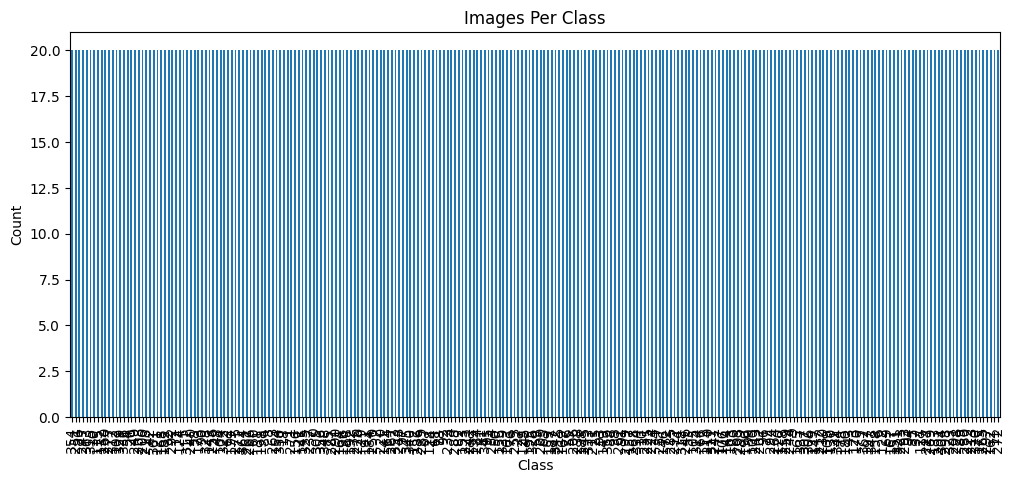

In [4]:
class_counts.plot(kind='bar', figsize=(12,5))

plt.title("Images Per Class")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

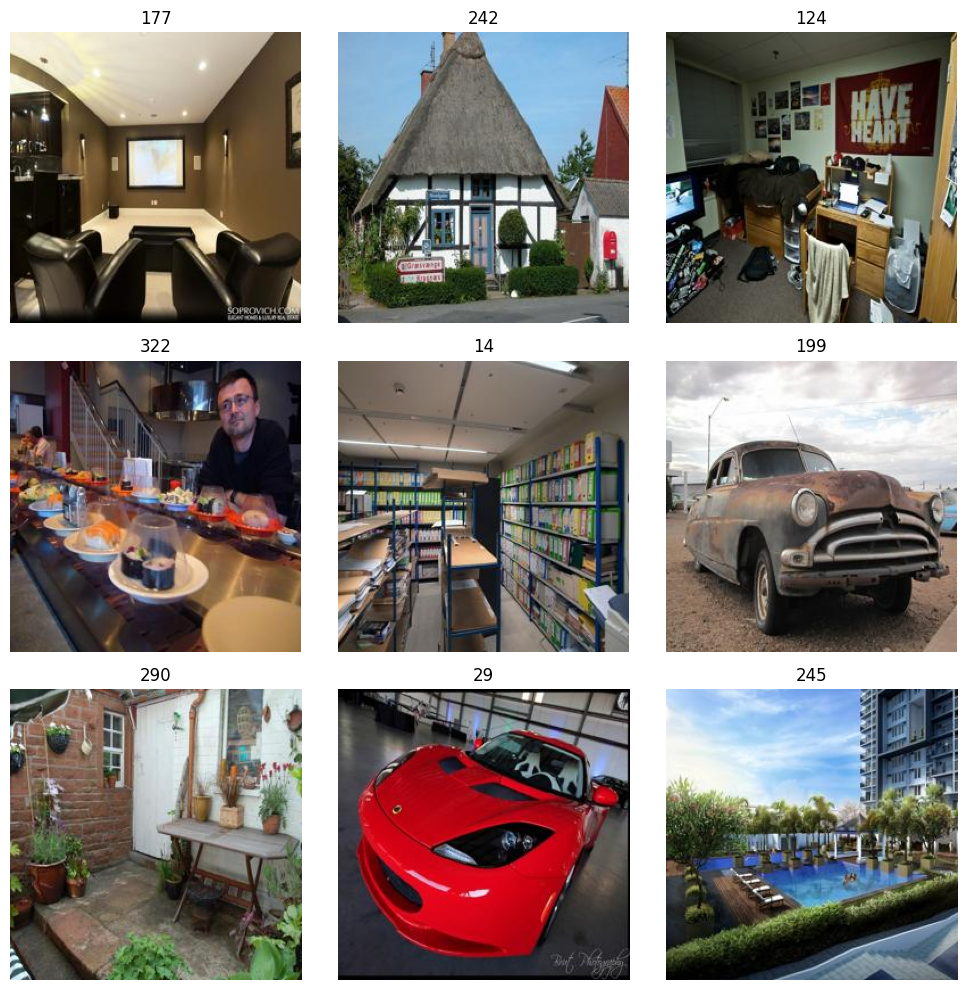

In [5]:
image_dir = "../data/images"

sample_rows = train_df.sample(9)

plt.figure(figsize=(10,10))

for i, (_, row) in enumerate(sample_rows.iterrows()):
    
    image_path = os.path.join(image_dir, row['filename'])
    
    img = Image.open(image_path)
    
    plt.subplot(3,3,i+1)
    plt.imshow(img)
    plt.title(row['label'])
    plt.axis("off")

plt.tight_layout()
plt.show()

In [6]:
import sys
sys.path.append("..")

from dataset import FewShotImageDataset
from transforms import train_transform
from episode_sampler import EpisodeSampler

dataset = FewShotImageDataset(
    csv_file="../data/train.csv",
    image_dir="../data/images",
    transform=train_transform
)

sampler = EpisodeSampler(
    dataset=dataset,
    n_way=5,
    n_shot=5,
    n_query=5
)

support_images, support_labels, query_images, query_labels, selected_classes = sampler.sample_episode()

print("Selected classes:", selected_classes)
print("Support images:", support_images.shape)
print("Support labels:", support_labels)
print("Query images:", query_images.shape)
print("Query labels:", query_labels)

Selected classes: [np.int64(102), np.int64(280), np.int64(162), np.int64(228), np.int64(267)]
Support images: torch.Size([25, 3, 84, 84])
Support labels: tensor([0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 3, 3, 3, 3, 3, 4, 4, 4, 4,
        4])
Query images: torch.Size([25, 3, 84, 84])
Query labels: tensor([0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 3, 3, 3, 3, 3, 4, 4, 4, 4,
        4])


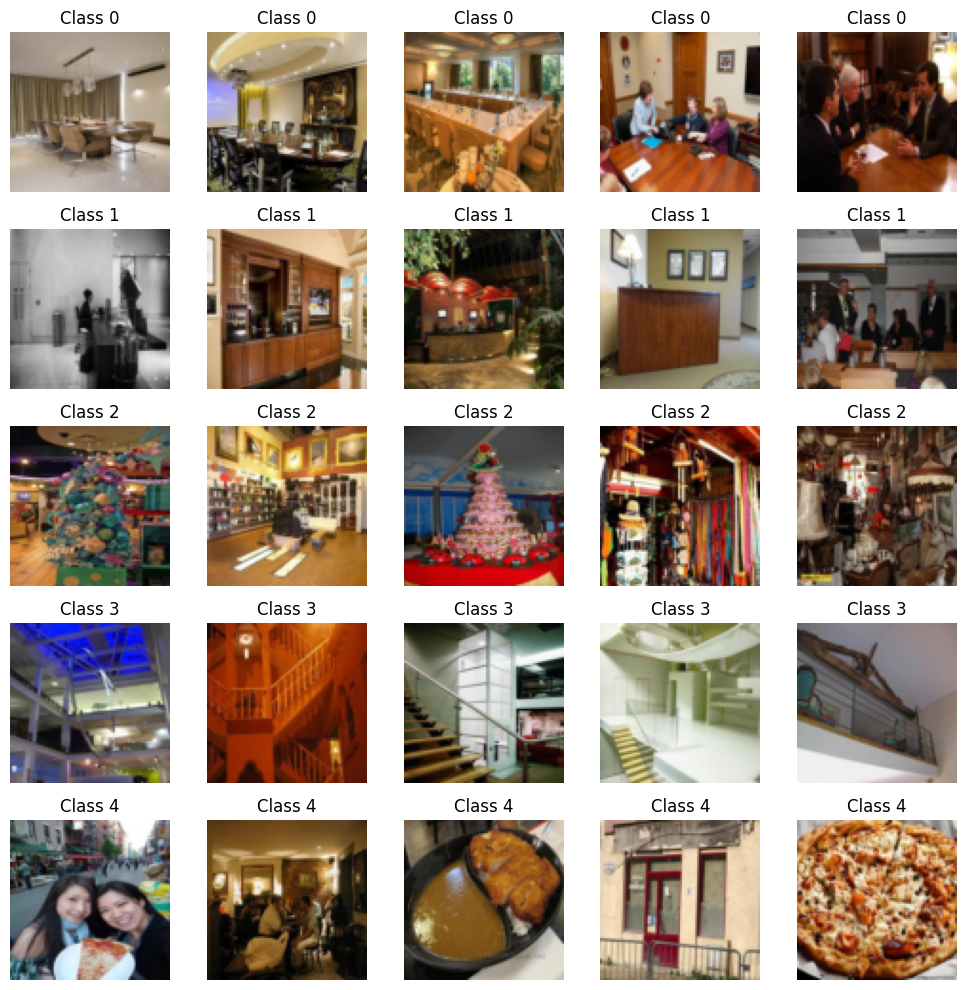

In [9]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(5, 5, figsize=(10,10))

for i in range(25):

    img = support_images[i].permute(1,2,0).numpy()

    axes[i//5, i%5].imshow(img)

    axes[i//5, i%5].set_title(
        f"Class {support_labels[i].item()}"
    )

    axes[i//5, i%5].axis("off")

plt.tight_layout()
plt.show()